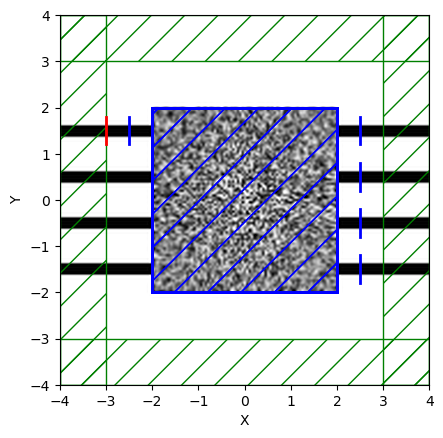

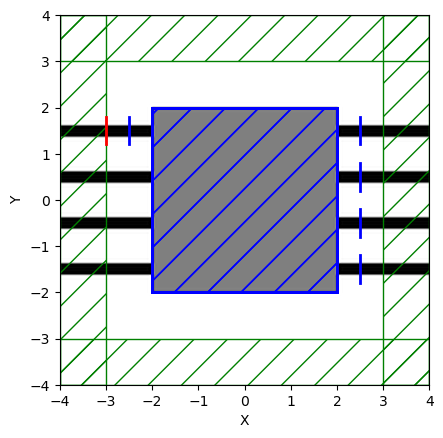

In [12]:
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product as vjp
from autograd import grad as ag_grad
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

Si = mp.Medium(index=3.4)

resolution = 20

# cell size
Sx = 8
Sy = 8
cell_size = mp.Vector3(Sx, Sy)
pml_layers = [mp.PML(1.0)]

# source
fcen = 1 / 1.55
width = 0.6
fwidth = width * fcen
source_center = mp.Vector3(-3, 1.5, 0)
source_size = mp.Vector3(0, 0.6, 0)
src = mp.GaussianSource(frequency = fcen, fwidth=fwidth)
source = [
    mp.EigenModeSource(
        src,
        eig_band=1,
        eig_match_freq=True,
        direction=mp.X,
        size=source_size,
        center=source_center,
    )
]

#design region
Dx = 4
Dy = 4
design_region_resolution = int(resolution)

Nx = int(Dx * design_region_resolution) + 1
Ny = int(Dy * design_region_resolution) + 1

design_variables = mp.MaterialGrid(mp.Vector3(Nx,Ny),
                                   mp.air,
                                   Si,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(),
                                                  size=mp.Vector3(Dx, Dy)))

# geometry
wg_width = 0.25

wg_length = (Sx - Dx) / 2

x_in = -Dx/2 - wg_length/2
x_out = Dx/2 + wg_length/2

# 4개 포트의 y좌표
# 위에서부터 port 1, 2, 3, 4
port_ys = [1.5, 0.5, -0.5, -1.5]

geometry = []

# input / output waveguides
for y in port_ys:
    # input waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_in, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

    # output waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_out, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# OSU design region
geometry.append(
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=design_variables
    )
)

sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    eps_averaging=False,
    resolution=resolution,
)
#input monitor
TE_in = mpa.EigenmodeCoefficient(
    sim,
    mp.Volume(
        center=mp.Vector3(-2.5, 1.5, 0),
        size=mp.Vector3(y=0.6)
    ),
    mode=1,
    forward=True
)

# ouput monitor 
TE_out = []

for y in port_ys:
    TE_out.append(
        mpa.EigenmodeCoefficient(
            sim,
            mp.Volume(
                center=mp.Vector3(2.5, y, 0),
                size=mp.Vector3(y=0.6)
            ),
            mode=1
        )
    )

ob_list = [TE_in] + TE_out

# FOM
def J(a_in, a1, a2, a3, a4):
    Pin = npa.abs(a_in) ** 2 + 1e-12

    powers = npa.array([
        npa.abs(a1) ** 2,
        npa.abs(a2) ** 2,
        npa.abs(a3) ** 2,
        npa.abs(a4) ** 2
    ])

    T = powers / Pin

    target = 0.25

    mse = npa.mean((T - target) ** 2)

    fom = 1 - mse / (target ** 2)

    return fom


opt = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=J,
    objective_arguments=ob_list,
    design_regions=[design_region],
    fcen=fcen,
    df=0,
    nf=1,
)

x0 = np.random.rand(Nx * Ny)
opt.update_design([x0])

opt.plot2D(True, frequency=1 / 1.55)
plt.show()

x0 = 0.5 * np.ones((Nx * Ny, ))
opt.update_design([x0])

opt.plot2D(True)
plt.show()



In [13]:
evaluation_history = []
cur_iter = [0]


def get_gradient_array(dJ_du):
    g = dJ_du

    # Meep 버전에 따라 list/tuple로 감싸져 나오는 경우 대비
    while isinstance(g, (list, tuple)):
        g = g[0]

    g = np.real(np.squeeze(np.asarray(g)))
    g = g.reshape(-1)

    return g


def f(v, gradient):
    cur_iter[0] += 1

    fom, dJ_du = opt([v], need_gradient=True)

    fom = float(np.real(np.squeeze(fom)))

    if gradient.size > 0:
        g = get_gradient_array(dJ_du)

        if g.size != Nx * Ny:
            raise ValueError(
                f"Gradient size mismatch: got {g.size}, expected {Nx * Ny}"
            )

        gradient[:] = g

    evaluation_history.append(fom)

    print(f"iter {cur_iter[0]:03d} | FOM = {fom:.8f}")

    return fom


algorithm = nlopt.LD_MMA
solver = nlopt.opt(algorithm, Nx * Ny)

solver.set_lower_bounds(np.zeros(Nx * Ny))
solver.set_upper_bounds(np.ones(Nx * Ny))

solver.set_max_objective(f)
solver.set_maxeval(10)
solver.set_ftol_rel(1e-5)

x = solver.optimize(x0)

opt.update_design([x])

Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 001 | FOM = 0.57324858
Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 002 | FOM = 0.62289354
Starting forward run...


...

Calculating gradient...
iter 008 | FOM = 0.97550955
Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 009 | FOM = 0.94872892
Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 010 | FOM = 0.98435669


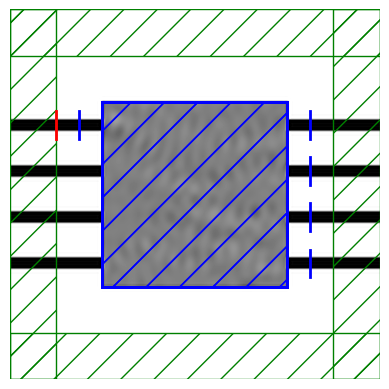

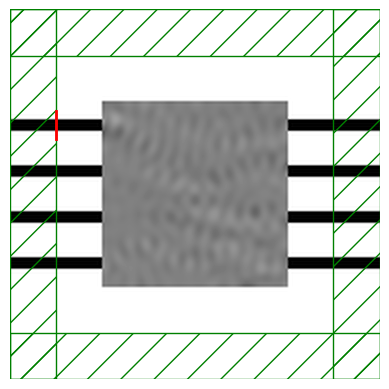

In [14]:
opt.update_design([x])
opt.plot2D(
    True,
    plot_monitors_flag=False,
    output_plane=mp.Volume(center=(0,0,0), size=(8,8,0))
)
plt.axis("off")

opt.update_design([x])

plt.figure()
sim.plot2D(
    output_plane=mp.Volume(center=mp.Vector3(), size=mp.Vector3(8,8,0)),
    labels=False
)
plt.axis("off")
plt.show()

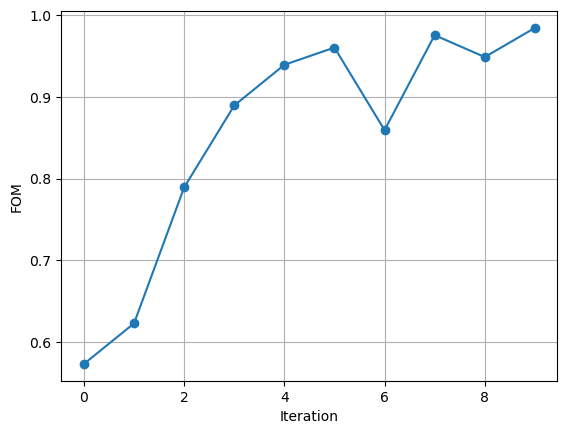

In [15]:
plt.figure()
plt.plot(evaluation_history, "o-")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("FOM")
plt.show()